In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# Исходные данные
S = "GCAAUCGCAUGC"
n = len(S)
row_labels = [f"{i} ({S[i]})" for i in range(n)]

print("Последовательность (первичная структура):", S)

Последовательность (первичная структура): GCAAUCGCAUGC


In [10]:
# 2. Матрица смежности
adj = np.zeros((n, n), dtype=int)
for i in range(n-1):
    adj[i, i+1] = 1
    adj[i+1, i] = 1

df = pd.DataFrame(adj, index=row_labels, columns=row_labels)
df

,0 (G),1 (C),2 (A),3 (A),4 (U),5 (C),6 (G),7 (C),8 (A),9 (U),10 (G),11 (C)
0 (G),0,1,0,0,0,0,0,0,0,0,0,0
1 (C),1,0,1,0,0,0,0,0,0,0,0,0
2 (A),0,1,0,1,0,0,0,0,0,0,0,0
3 (A),0,0,1,0,1,0,0,0,0,0,0,0
4 (U),0,0,0,1,0,1,0,0,0,0,0,0
5 (C),0,0,0,0,1,0,1,0,0,0,0,0
6 (G),0,0,0,0,0,1,0,1,0,0,0,0
7 (C),0,0,0,0,0,0,1,0,1,0,0,0
8 (A),0,0,0,0,0,0,0,1,0,1,0,0
9 (U),0,0,0,0,0,0,0,0,1,0,1,0


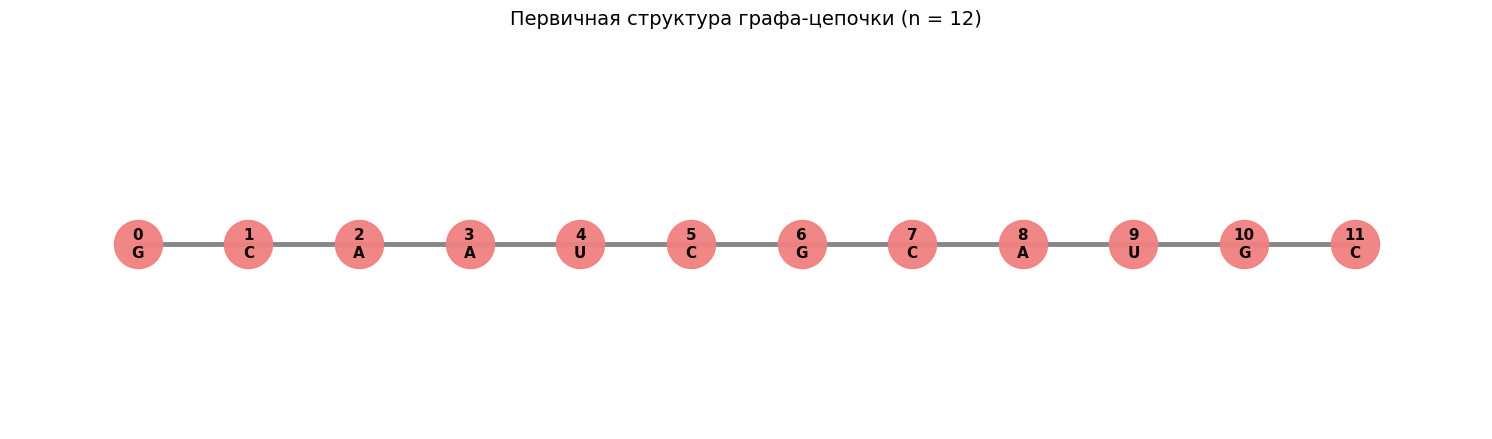

In [15]:
# Создаём граф-цепочку
G = nx.path_graph(n)

# Ровное горизонтальное расположение с большим расстоянием
pos = {i: (i * 1.9, 0) for i in range(n)}   # чуть увеличил шаг

fig = plt.figure(figsize=(19, 4.8))
ax = fig.add_subplot(111)

nx.draw(G, pos,
        ax=ax,
        labels={i: f"{i}\n{S[i]}" for i in range(n)},
        with_labels=True,
        node_color='lightcoral',
        node_size=1200,
        font_size=11,
        font_weight='bold',
        edge_color='gray',
        width=3.5,
        alpha=0.95)

plt.title('Первичная структура графа-цепочки (n = 12)', fontsize=14, pad=25)
plt.axis('off')
plt.show()

Максимальное число пар: 4

=== Таблица DP алгоритма Нуссинова ===
        0 (G)  1 (C)  2 (A)  3 (A)  4 (U)  5 (C)  6 (G)  7 (C)  8 (A)  9 (U)  10 (G)  11 (C)
0 (G)       0      0      0      0      1      2      2      3      3      3       3       4
1 (C)       0      0      0      0      1      1      2      2      2      2       3       3
2 (A)       0      0      0      0      1      1      1      1      1      2       2       3
3 (A)       0      0      0      0      0      0      0      0      1      2       2       2
4 (U)       0      0      0      0      0      0      0      0      1      1       1       2
5 (C)       0      0      0      0      0      0      0      0      0      0       1       2
6 (G)       0      0      0      0      0      0      0      0      0      0       1       2
7 (C)       0      0      0      0      0      0      0      0      0      0       1       1
8 (A)       0      0      0      0      0      0      0      0      0      0       0       0
9 (U

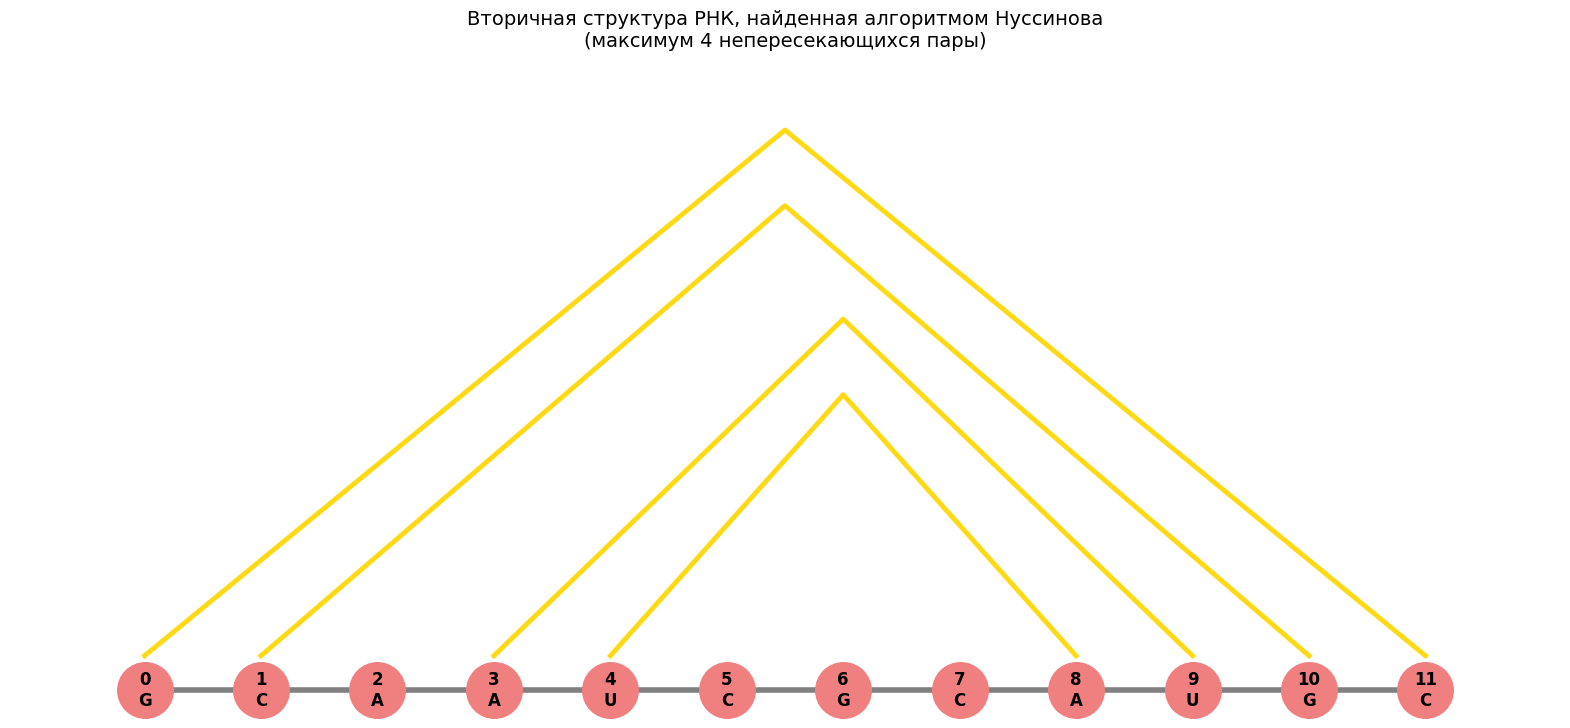

In [21]:
def is_complementary(a, b):
    return (a, b) in {('A','U'), ('U','A'), ('G','C'), ('C','G')}

# 1. Заполнение таблицы DP
dp = np.zeros((n, n), dtype=int)
for length in range(1, n):
    for i in range(n - length):
        j = i + length
        val1 = dp[i+1][j] if i+1 <= j else 0
        val2 = dp[i][j-1] if i <= j-1 else 0
        val3 = (dp[i+1][j-1] + 1 if is_complementary(S[i], S[j]) and i+1 <= j-1 else 0)
        val4 = max((dp[i][k] + dp[k+1][j] for k in range(i, j)), default=0)
        dp[i][j] = max(val1, val2, val3, val4)

print("Максимальное число пар:", dp[0, -1])

# Красивый вывод таблицы DP
labels = [f"{i} ({S[i]})" for i in range(n)]
dp_df = pd.DataFrame(dp, index=labels, columns=labels)
print("\n=== Таблица DP алгоритма Нуссинова ===")
print(dp_df.to_string())

# 2. Traceback — восстановление пар
def get_pairs(dp, S, i=0, j=None, pairs=None):
    if pairs is None: pairs = []
    if j is None: j = len(S)-1
    if i >= j: return pairs
    if dp[i][j] == dp[i+1][j]:
        return get_pairs(dp, S, i+1, j, pairs)
    if dp[i][j] == dp[i][j-1]:
        return get_pairs(dp, S, i, j-1, pairs)
    if is_complementary(S[i], S[j]) and dp[i][j] == dp[i+1][j-1] + 1:
        pairs.append((i, j))
        return get_pairs(dp, S, i+1, j-1, pairs)
    for k in range(i, j):
        if dp[i][j] == dp[i][k] + dp[k+1][j]:
            get_pairs(dp, S, i, k, pairs)
            get_pairs(dp, S, k+1, j, pairs)
            return pairs
    return pairs

pairs = get_pairs(dp, S)
print("\nНайденные пары (дуги):", pairs)

# 3. ИСПРАВЛЕННАЯ ВИЗУАЛИЗАЦИЯ
G = nx.path_graph(n)
pos = {i: (i * 2.0, 0) for i in range(n)}

fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111)

# Сначала рисуем дуги (вторичная структура)
for a, b in pairs:
    length = b - a
    height = 1.6 + 0.42 * length     #высота зависит от длины пары
    x1, y1 = pos[a]
    x2, y2 = pos[b]
    # Небольшой отступ от центра вершин, чтобы дуга не заходила внутрь
    offset = 0.38
    mid_x = (x1 + x2) / 2
    plt.plot([x1, mid_x, x2], 
             [y1 + offset, y1 + height, y2 + offset],
             color='gold', linestyle='-', linewidth=3.5, alpha=0.92)

# Затем первичные рёбра цепочки
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', width=4)

# Узлы
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightcoral', node_size=1600)

# Подписи
nx.draw_networkx_labels(G, pos, ax=ax,
                        labels={i: f"{i}\n{S[i]}" for i in range(n)},
                        font_size=12, font_weight='bold')

plt.title('Вторичная структура РНК, найденная алгоритмом Нуссинова\n(максимум 4 непересекающихся пары)', 
          fontsize=14, pad=40)
plt.axis('off')
plt.show()